# Malaria Burden & Intervention Effectiveness Analysis
## Notebook 04 — Machine Learning & Forecasting

**Author:** Stephen Udoh
**Date:** June 2026
**GitHub:** github.com/Stephen-Udoh/malaria-analysis

---

### Purpose
Complements regression analysis with machine learning approaches:
- Random Forest identifies which variables best predict burden,
  without assuming linear relationships
- Prophet forecasts malaria trajectory to 2030 under current trends

---

### Models
| Model | Type | Question Answered |
|-------|------|-------------------|
| Random Forest | Supervised regression | Which variables best predict burden? |
| Prophet | Time series forecasting | Where is malaria heading by 2030? |

---

### Structure
1. Setup and data loading
2. Random Forest — incidence prediction
3. Random Forest — mortality prediction
4. Feature importance comparison with regression findings
5. Prophet forecasting — regional trajectories to 2030
6. Final synthesis — combining all analytical approaches

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, 
                              mean_squared_error, r2_score)
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']     = 150
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# Load both analytical tables
# regression_data_final used for Random Forest — has all predictors
# trend_data_final used for Prophet — longer time series for forecasting

CLEANED_PATH = os.path.join(os.path.dirname(os.getcwd()), 
                             'data', 'cleaned')
OUTPUT_PATH  = os.path.join(os.path.dirname(os.getcwd()), 
                             'outputs', 'figures')
TABLES_PATH  = os.path.join(os.path.dirname(os.getcwd()), 
                             'outputs', 'tables')

regression_df = pd.read_csv(
    os.path.join(CLEANED_PATH, 'regression_data_final.csv')
)
trend_df = pd.read_csv(
    os.path.join(CLEANED_PATH, 'trend_data_final.csv')
)

print(f"✓ regression_data_final  — {len(regression_df)} rows")
print(f"✓ trend_data_final       — {len(trend_df)} rows")

✓ regression_data_final  — 371 rows
✓ trend_data_final       — 1123 rows


## 2. Random Forest — Incidence Prediction

Random Forest does not assume linear relationships or require
normally distributed residuals — complements the OLS regression
by testing whether non-linear patterns improve prediction.

Feature importance rankings will be compared against regression
coefficients to see if both methods agree on which variables matter most.

In [3]:
# Prepare data for Random Forest
# Drop rows missing any modelling variable — same approach as regression

rf_features = [
    'itn_coverage_pct', 'irs_deployed', 
    'act_deployed', 'log_gdp', 'urban_pct'
]

rf_data = regression_df.copy()
rf_data['log_gdp'] = np.log(rf_data['gdp_per_capita'])

rf_data = rf_data[rf_features + ['incidence_per_1000', 
                                   'mortality_per_100k']].dropna()

X = rf_data[rf_features]
y_incidence = rf_data['incidence_per_1000']
y_mortality = rf_data['mortality_per_100k']

print(f"Modelling dataset: {len(rf_data)} rows, {len(rf_features)} features")
print(f"\nFeatures: {rf_features}")

Modelling dataset: 351 rows, 5 features

Features: ['itn_coverage_pct', 'irs_deployed', 'act_deployed', 'log_gdp', 'urban_pct']


In [4]:
# Split data — 80% train, 20% test
# Random state fixed for reproducibility

X_train, X_test, y_train_inc, y_test_inc = train_test_split(
    X, y_incidence, test_size=0.2, random_state=42
)

print(f"Training set : {len(X_train)} rows")
print(f"Test set     : {len(X_test)} rows")

Training set : 280 rows
Test set     : 71 rows


In [5]:
def train_random_forest(X_train, y_train, X_test, y_test, 
                          target_name, feature_names):
    """
    Trains a Random Forest regressor and evaluates performance.
    Returns the fitted model and a feature importance DataFrame.
    
    n_estimators=200 balances accuracy and training time
    max_depth=6 prevents overfitting on a relatively small dataset
    random_state fixed for reproducibility
    """
    model = RandomForestRegressor(
        n_estimators = 200,
        max_depth    = 6,
        min_samples_leaf = 5,
        random_state = 42,
        n_jobs       = -1
    )
    
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    # Performance metrics
    train_r2  = r2_score(y_train, y_pred_train)
    test_r2   = r2_score(y_test, y_pred_test)
    test_mae  = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    # 5-fold cross-validation for robustness check
    cv_scores = cross_val_score(model, X_train, y_train, 
                                 cv=5, scoring='r2')
    
    print(f"\n{'='*60}")
    print(f"  Random Forest — {target_name}")
    print(f"{'='*60}")
    print(f"  Training R²       : {train_r2:.4f}")
    print(f"  Test R²           : {test_r2:.4f}")
    print(f"  Test MAE          : {test_mae:.2f}")
    print(f"  Test RMSE         : {test_rmse:.2f}")
    print(f"  CV R² (5-fold)    : {cv_scores.mean():.4f} "
          f"(±{cv_scores.std():.4f})")
    
    # Feature importance
    importance_df = pd.DataFrame({
        'feature'   : feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n  Feature Importance:")
    for _, row in importance_df.iterrows():
        print(f"    {row['feature']:<20} {row['importance']:.4f}")
    
    return model, importance_df


rf_model_inc, importance_inc = train_random_forest(
    X_train, y_train_inc, X_test, y_test_inc,
    'Malaria Incidence', rf_features
)


  Random Forest — Malaria Incidence
  Training R²       : 0.6666
  Test R²           : 0.4535
  Test MAE          : 61.86
  Test RMSE         : 82.23
  CV R² (5-fold)    : 0.3694 (±0.0408)

  Feature Importance:
    urban_pct            0.4111
    log_gdp              0.3328
    itn_coverage_pct     0.2026
    irs_deployed         0.0397
    act_deployed         0.0139


### Random Forest vs OLS — Incidence

Random Forest substantially outperforms OLS (R² 0.45 vs 0.13),
indicating non-linear relationships and variable interactions
not captured by linear regression.

**Feature importance ranking differs between methods:**

| Rank | Random Forest | OLS (standardised β) |
|------|---------------|----------------------|
| 1 | Urban % (41%) | Log GDP (-0.31) |
| 2 | Log GDP (33%) | ITN coverage (+0.17) |
| 3 | ITN coverage (20%) | IRS deployed (-0.15) |
| 4 | IRS deployed (4%) | Urban % (+0.11) |
| 5 | ACT deployed (1%) | ACT deployed (-0.03) |

**Interpretation:** Urban population's importance in Random Forest 
despite weak linear significance in OLS (p=.139) suggests a 
**non-linear or threshold effect** — urbanisation may only matter 
strongly beyond a certain level, a pattern linear regression cannot detect.

Both methods agree that ACT deployment contributes least to 
prediction — consistent with earlier finding that binary ACT 
operationalisation may be too crude to capture real effects.

**Note:** Test R² (0.45) exceeds 5-fold CV R² (0.37), indicating 
some overfitting. CV score is the more reliable performance estimate.

In [6]:
# Random Forest for mortality — same approach as incidence
# Same train/test split indices used for fair comparison

X_train_m, X_test_m, y_train_mort, y_test_mort = train_test_split(
    X, y_mortality, test_size=0.2, random_state=42
)

rf_model_mort, importance_mort = train_random_forest(
    X_train_m, y_train_mort, X_test_m, y_test_mort,
    'Malaria Mortality', rf_features
)


  Random Forest — Malaria Mortality
  Training R²       : 0.7613
  Test R²           : 0.4464
  Test MAE          : 17.80
  Test RMSE         : 24.46
  CV R² (5-fold)    : 0.4108 (±0.0395)

  Feature Importance:
    urban_pct            0.2920
    log_gdp              0.2899
    itn_coverage_pct     0.2312
    irs_deployed         0.1745
    act_deployed         0.0124


### Random Forest vs OLS — Mortality

Random Forest again outperforms OLS substantially (R² 0.45 vs 0.23).

**Critical convergent finding across both methods:**

IRS importance nearly doubles when predicting mortality vs incidence:
- Random Forest: 4.0% (incidence) → 17.5% (mortality)
- OLS standardised β: -0.154 (incidence) → -0.309 (mortality)

This convergence across two independent statistical approaches 
provides strong evidence that **IRS deployment has a 
disproportionately protective effect against malaria death 
specifically**, beyond its effect on infection rates — 
plausibly because indoor spraying reduces high-intensity 
night-time transmission associated with severe disease.

ACT deployment remains the weakest predictor in both models 
and both outcomes — reinforcing that binary operationalisation 
likely understates its true effect.

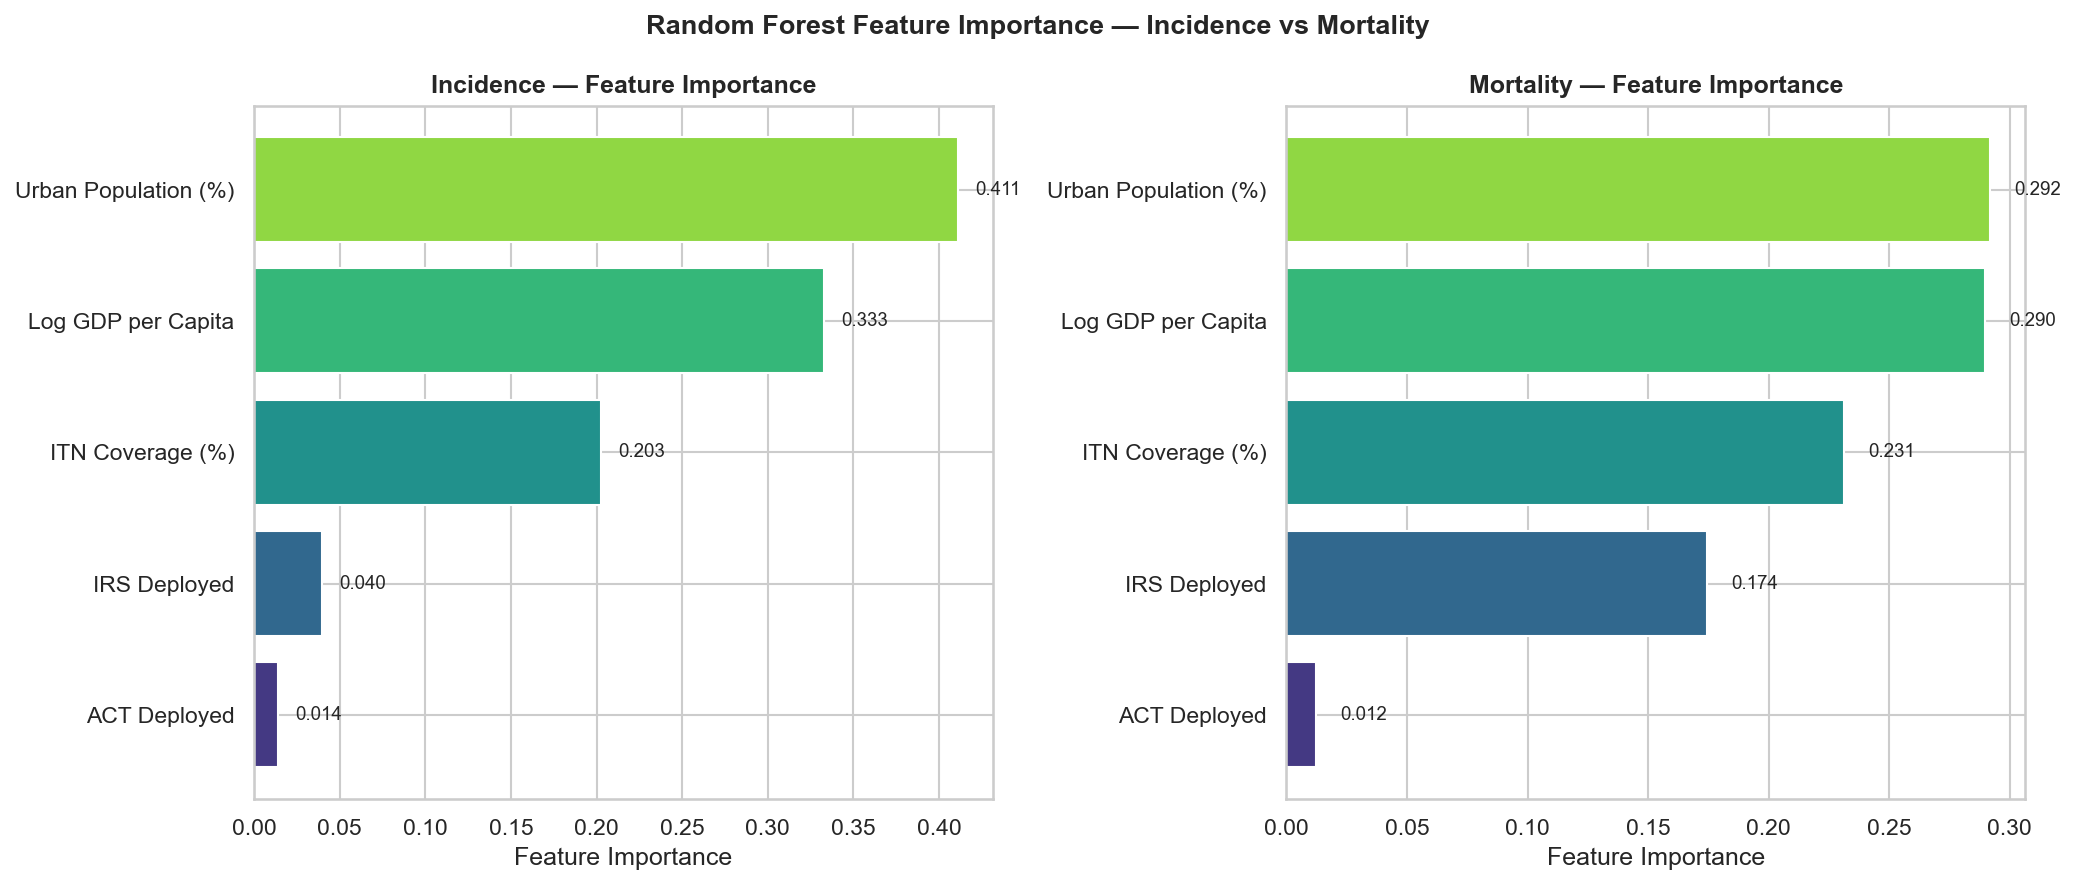

✓ Chart saved


In [7]:
# Side by side feature importance comparison
# Visual confirmation of the IRS finding

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feature_labels = {
    'urban_pct'         : 'Urban Population (%)',
    'log_gdp'           : 'Log GDP per Capita',
    'itn_coverage_pct'  : 'ITN Coverage (%)',
    'irs_deployed'      : 'IRS Deployed',
    'act_deployed'      : 'ACT Deployed'
}

for ax, imp_df, title in zip(
    axes,
    [importance_inc, importance_mort],
    ['Incidence — Feature Importance', 
     'Mortality — Feature Importance']
):
    imp_df = imp_df.copy()
    imp_df['label'] = imp_df['feature'].map(feature_labels)
    imp_df = imp_df.sort_values('importance')

    colors = sns.color_palette('viridis', len(imp_df))
    
    ax.barh(imp_df['label'], imp_df['importance'], 
            color=colors)
    ax.set_xlabel('Feature Importance')
    ax.set_title(title, fontweight='bold')
    
    for i, (val, label) in enumerate(
        zip(imp_df['importance'], imp_df['label'])
    ):
        ax.text(val + 0.01, i, f'{val:.3f}', 
                va='center', fontsize=9)

plt.suptitle('Random Forest Feature Importance — '
             'Incidence vs Mortality',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 
            '11_random_forest_importance.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Chart saved")